# Hirano MSC-LS circuit atlas and two-fault diagnosis

This notebook turns the released `experiment-2025-sep` Figure-9 circuit into a
semantic circuit atlas, then maps the exact two-fault witnesses back to gates,
qubits, syndrome rounds, and detector records.

**Bottom line.** The rotated surface patch has spatial distance 5, but the
merged boundary is measured only three times. That distance-3 spacetime neck
has an undetected-logical fault distance of 3, yet a decoder can fail on two
faults. Postselecting every detection event instead rejects those two-fault
histories and exposes the three-fault scaling. The observed fitted exponent
near 2.7 is a finite-window mixture of nonzero $p^2$ and larger $p^3$ terms; it
is not a fractional code distance.

The notebook performs exact detector-error-model enumeration and deterministic
Pauli injections only. It does **not** run the tens-of-billions-shot
full-postselection simulations.

The Figure-9 experiment is a **Clifford stabilizer diagnostic**: the already
prepared logical `+` or `0` Steane state is initialized ideally, transferred,
and measured. It is not a simulation of the non-Clifford magic-state injection
and cultivation stages.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymatching
from scipy.optimize import nnls
import stim
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
assert (ROOT / "src" / "lattice_surgery_error_detection.py").exists()
sys.path.insert(0, str(ROOT / "audit"))

from fig9_postselection_audit import KNOWN_AMBIGUITIES
from hirano_protocol_notebook_helpers import (
    build_protocol,
    detector_registry,
    deterministic_fault_circuit,
    fault_table,
    hirano_interface_round_macro_table,
    plot_grouped_hirano_interface_round,
    plot_protocol_layout,
    qubit_legend,
    semantic_labels,
    show_timeline,
    show_timeslices,
    single_fault_decoder_failures,
    witness_summary,
)

print(f"Stim {stim.__version__}; PyMatching {pymatching.__version__}")
print("Released source under audit: src/lattice_surgery_error_detection.py")
print("No Monte Carlo shots are used in this notebook.")

Stim 1.16.0; PyMatching 2.4.0
Released source under audit: src/lattice_surgery_error_detection.py
No Monte Carlo shots are used in this notebook.


## 1. Paper claim versus the two code branches

Section III A of the paper explicitly says that color-code syndromes and the
merged-boundary $Z$ parities are used for **error detection** (reject on a
nontrivial result), while rotated-surface-code stabilizers use **error
correction**. Figure 9 later describes an extra noiseless surface syndrome
round followed by postselection.

The released implementation exposes a parameter named
`full_post_selection`—there is no `full_error_detection` parameter:

- `False`: 40 selected color/interface/heuristic surface detectors are
  postselected; the remaining surface history is decoded. Four extra noisy
  surface rounds are appended after the first recovery round.
- `True`: the extra four rounds are omitted and **every one of the 135
  detectors** is postselected. The released Figure-9 counts match this branch,
  so this is stronger postselection than the general decoded-surface statement.

Source paper: `audit/Efficient magic state cultivation with lattice
surgery.pdf`, especially Figures 5, 6, and 9 and Section III A.

In [2]:
branch_rows = []
for full in (False, True):
    wrapper = build_protocol("+", error_probability=0.001, full_post_selection=full)
    circuit = wrapper.circuit.circuit
    postselected = {item.id for item in wrapper.circuit.detectors_for_post_selection}
    tags = []
    for instruction in circuit.flattened():
        if instruction.name == "DETECTOR":
            tags.append(instruction.tag or "untagged")
    branch_rows.append(
        {
            "full_post_selection": full,
            "TICKs": circuit.num_ticks,
            "measurements": circuit.num_measurements,
            "detectors": circuit.num_detectors,
            "postselected_detectors": len(postselected),
            "decoded_detector_columns": circuit.num_detectors - len(postselected),
            "postselected tags": dict(pd.Series([tags[i] for i in postselected]).value_counts()),
        }
    )
branch_table = pd.DataFrame(branch_rows)
display(branch_table)

,full_post_selection,TICKs,measurements,detectors,postselected_detectors,decoded_detector_columns,postselected tags
0,False,56,266,231,40,191,"{'POST-SELECTION': 22, 'SURFACE-X': 18}"
1,True,32,170,135,135,0,"{'SURFACE-X': 53, 'SURFACE-Z': 48, 'POST-SELEC..."


## 2. Protocol schedule in the released circuit

Stim's tick number is a circuit-layer coordinate, not a syndrome-round number.
The two tagged `Stabilize_*` ticks are zero-duration layering separators added
inside the pipelined color-code schedule. This is the most useful coarse map:

| Stim interval | Released-code action |
|---|---|
| before / ticks 0–5 | initialize the distance-5 surface data in $|+\rangle$ and complete one ordinary surface-check round |
| ticks 6–11 | Hirano lattice-surgery Z-syndrome round 1; remove the conflicting top surface-X checks; begin the pipelined direct color checks |
| tick 12 | tagged `Stabilize_0` separator |
| ticks 13–18 | Hirano lattice-surgery Z-syndrome round 2; continue/finish the pipelined color checks |
| tick 19 | tagged `Stabilize_1` separator |
| ticks 20–25 | Hirano lattice-surgery Z-syndrome round 3; finish direct checks; destructively X-measure Steane data and obtain $X_{ab}$ |
| ticks 26–31 | recover $X_{ab}$ and $X_{cd}$ and perform one ordinary surface round |
| ticks 32–55 | only when `full_post_selection=False`: four further ordinary surface rounds for decoding |
| after the last tick | noiseless destructive X (`+` probe) or Z (`0` probe) surface readout and `L0` parity |

The logical content agrees with the supplied schedule: the three interface
checks are $Z_{1a}$, $Z_{35bc}$, and $Z_{de}$; the direct color checks are
interleaved; demolition supplies the missing second X checks; and compatible
surface checks continue throughout. The implementation is more pipelined than
the four-row conceptual table: a two-ancilla superdense extraction can begin in
one Hirano interface round and its ancilla readouts can occur in the next.
Therefore the timeline below labels each superdense **ancilla half and
readout basis**, instead of incorrectly assigning every raw ancilla bit to a
complete stabilizer.

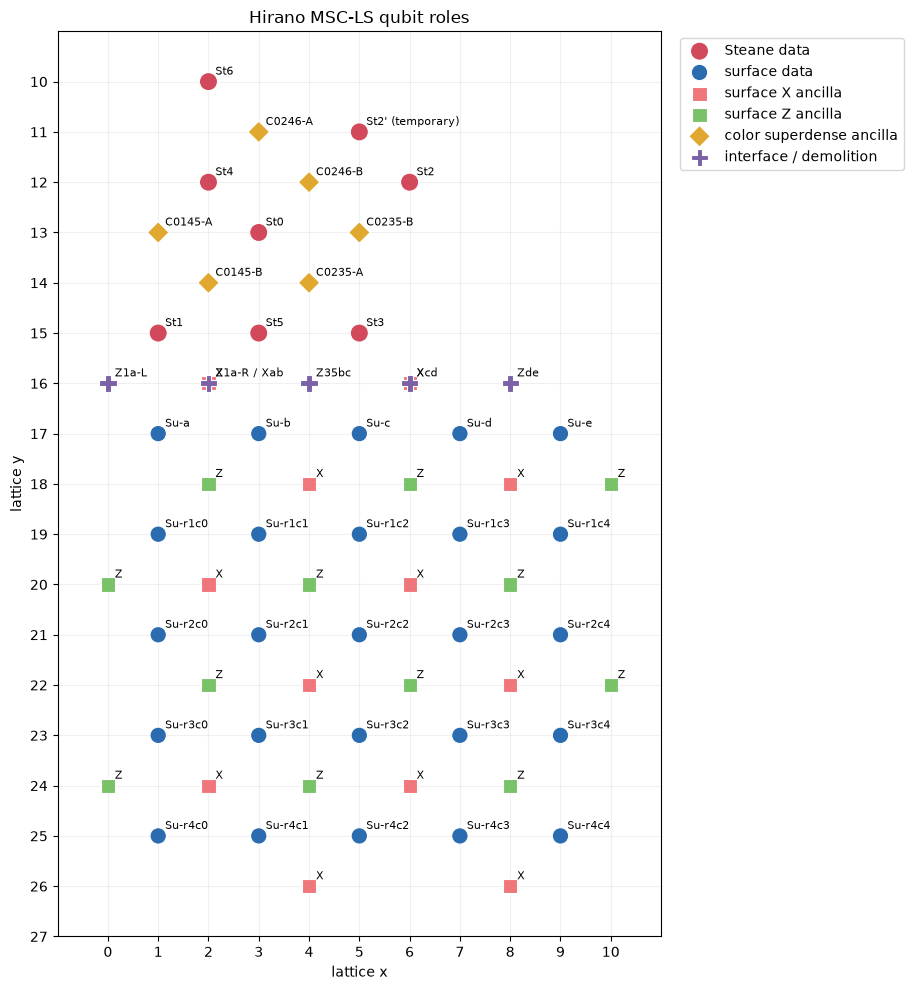

In [3]:
noiseless = build_protocol("+", error_probability=0.0, full_post_selection=False)
labels = semantic_labels(noiseless)
legend = qubit_legend(noiseless)
# display(legend[legend["family"] != "surface-check ancilla"])
plot_protocol_layout(noiseless);

### Gate-order timeline of Hirano's three merged-boundary rounds

The diagram is produced by Stim—not by printing circuit text—and removes the
hundreds of coordinate-only qubit rows. Qubit lines are renamed semantically:
`St*` is Steane/color data, `Su-*` is surface data/checks, `C*` is a color
superdense ancilla half, and `I:*` is an interface/demolition role. Scroll both
horizontally and vertically.

In [4]:
show_timeline(
    noiseless.circuit.circuit,
    labels,
    ticks=range(6, 26),
    zoom=1.45,
    annotation_font_size=14,
)

### Literal Stim geometry during Hirano interface round 1

This is Stim's timeslice view. Use it together with the semantic layout above:
the timeslice answers *where* simultaneous operations happen, while the
timeline answers *in what order* records and detectors are produced.

In [5]:
show_timeslices(
    noiseless.circuit.circuit,
    labels,
    ticks=range(6, 12),
    zoom=0.9,
)

### All three Hirano interface rounds, deinterleaved into operation-family macro-ticks

**Terminology.** “Interface repetition” was audit shorthand. Hirano's source
comments call these the first, second, and third *round of lattice-surgery Z
syndrome measurements*. This notebook now calls them **Hirano interface rounds
1–3**. They are not individual Stim ticks: the outer builder advances each
generator round through six executable layers.

The literal Stim timeslices above answer what happens in each **executable
hardware layer**. They can obscure the protocol structure because ordinary
surface and interface ancilla circuits require reset, collision-free CNOT
sublayers, and readout.

The next three figures answer the barrier-collapsed question: *what are the
logical operation groups inside each Hirano interface round?* Every panel
contains one family and nothing else. For rounds 1 and 2:

- `I`: all three interface parities $Z_{1a}$, $Z_{35bc}$, and $Z_{de}$;
- `S`: every compatible ordinary surface stabilizer, collapsed into one panel;
- `B`: preparation/entangling of the three color-ancilla pairs;
- `Z`: the Steane Z-stabilizer couplings;
- `X`: the Steane X-stabilizer couplings—present for 0235/0246 in color round 1,
  absent in color round 2;
- `M`: ancilla disentangling/readout and the postselected color record.

Round 3 replaces the direct color ancilla sequence with demolition groups:
Steane-data `MX`, the reused `q23` $X_{ab}$ ancilla, the three derived color-X
parities, and recovery of surface checks $X_{ab},X_{cd}$.

These are **conceptual macro-ticks, not executable Stim `TICK`s**. Several
arrows in a color-coupling panel share an ancilla. Since this view intentionally
collapses barriers, it collects a complete logical check even when the released
ZXZ generator pipelines its CNOTs/readouts across a source-code round boundary.
The macro tables say which abstraction is being used.

The apparent missing `Z1a-L` in the literal round-1 plot is real and
intentional. Round 1 uses `Z1a-R` at $(2,16)$; round 2 uses
`Z1a-L` at $(0,16)$; round 3 returns to `Z1a-R`. Consecutive left-boundary
outcomes are compared even though the physical ancilla site alternates.

Hirano interface round 1


,Hirano interface round,macro-tick,only operation family shown,checks / actions,relation to executable schedule
0,1,I,interface ZZ checks,"Z1a, Z35bc, Zde","Uses Z1a-R at (2,16); Z1a-L is idle. Each anci..."
1,1,S,compatible surface checks,all ordinary surface X/Z checks except the con...,"Collapsed stabilizer view; reset, four CNOT su..."
2,1,B,color-ancilla Bell preparation,"prepare the 0145, 0235, and 0246 two-ancilla p...",One conceptual preparation group.
3,1,Z,Steane Z-check coupling,"Z0145, Z0235, Z0246",All data-to-ancilla couplings are collected he...
4,1,X,Steane X-check coupling,"X0235, X0246; X0145 is deliberately omitted",All ancilla-to-data couplings are collected he...
5,1,M,color-ancilla disentangling/readout,MX/MZ ancilla readouts and postselected color ...,Readouts are staggered by the released pipeline.


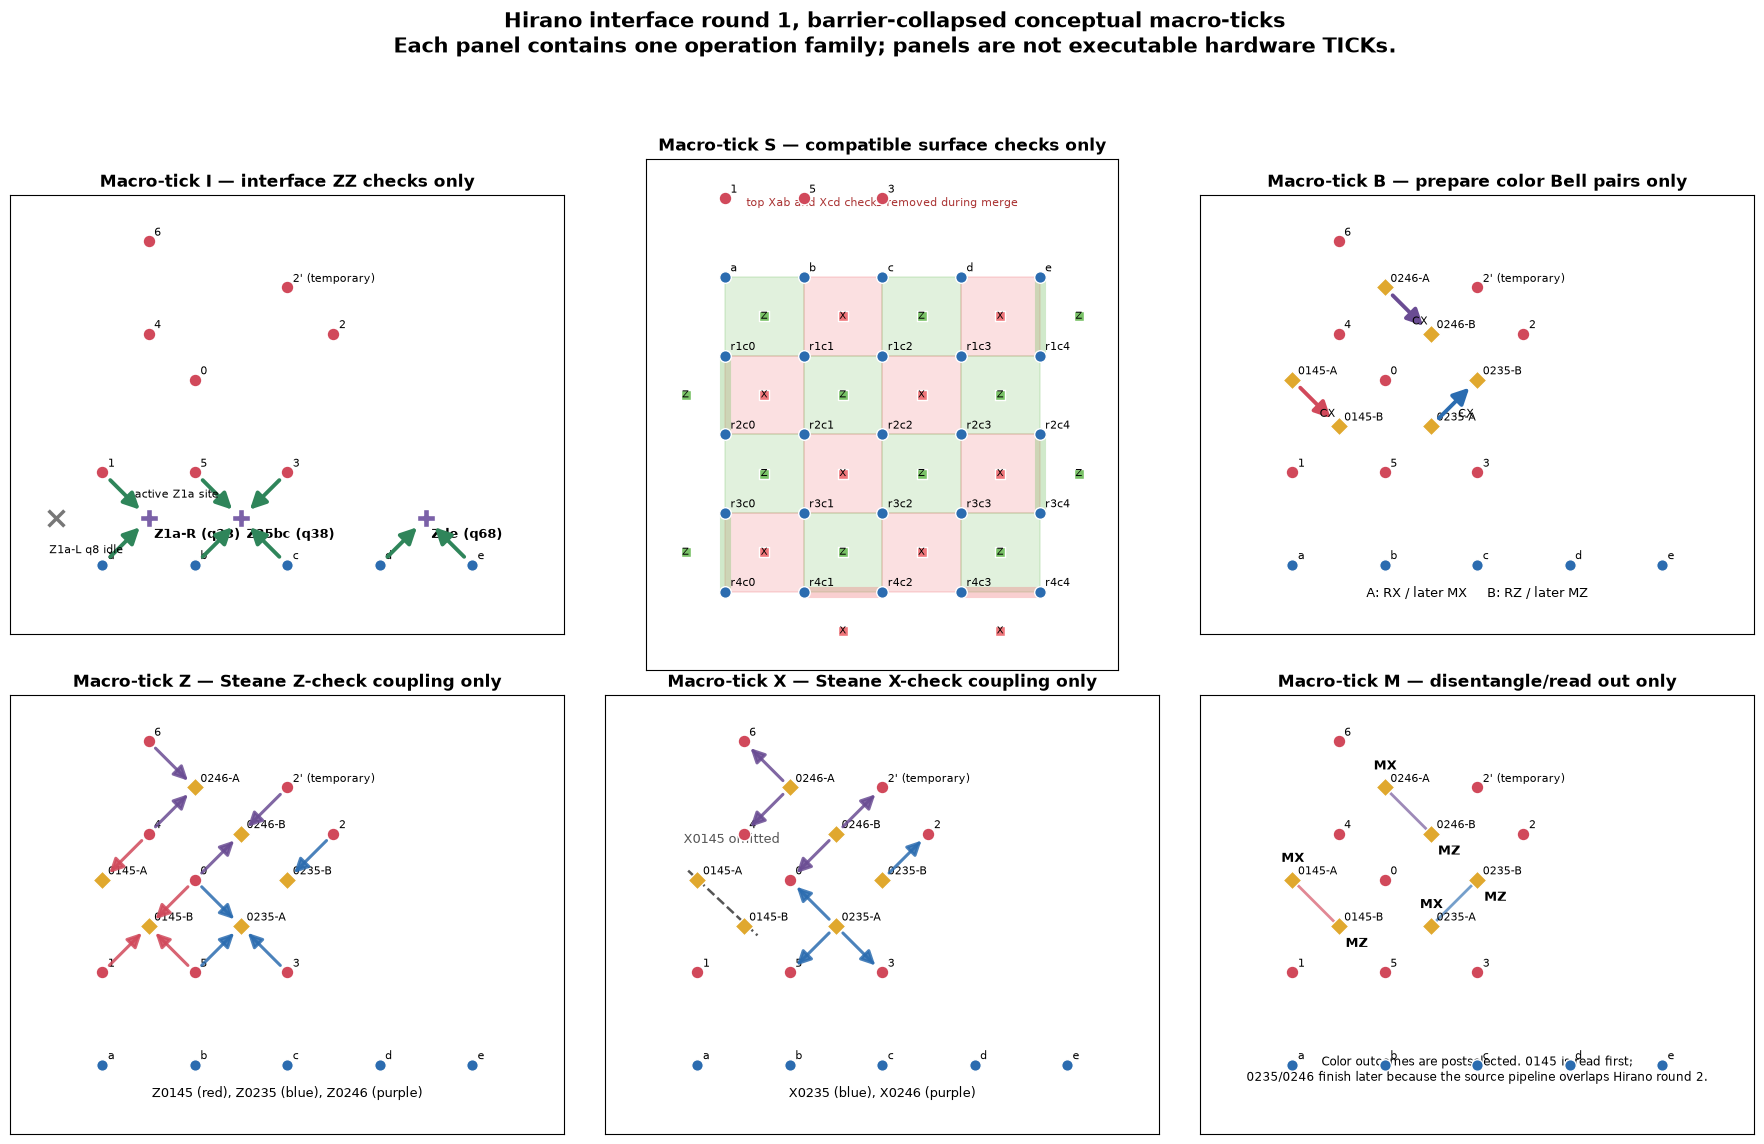

Hirano interface round 2


,Hirano interface round,macro-tick,only operation family shown,checks / actions
0,2,I,interface ZZ checks,"Z1a (left site), Z35bc, Zde"
1,2,S,compatible surface checks,all ordinary surface X/Z checks except top Xab...
2,2,B,color-ancilla Bell preparation,"prepare 0145, 0235, and 0246 pairs for the sec..."
3,2,Z,Steane Z-check coupling,"Z0145, Z0235, Z0246"
4,2,X,Steane X-check coupling,none in the second direct color extraction
5,2,M,color-ancilla disentangling/readout,MX/MZ readouts; retain the direct Z-check results


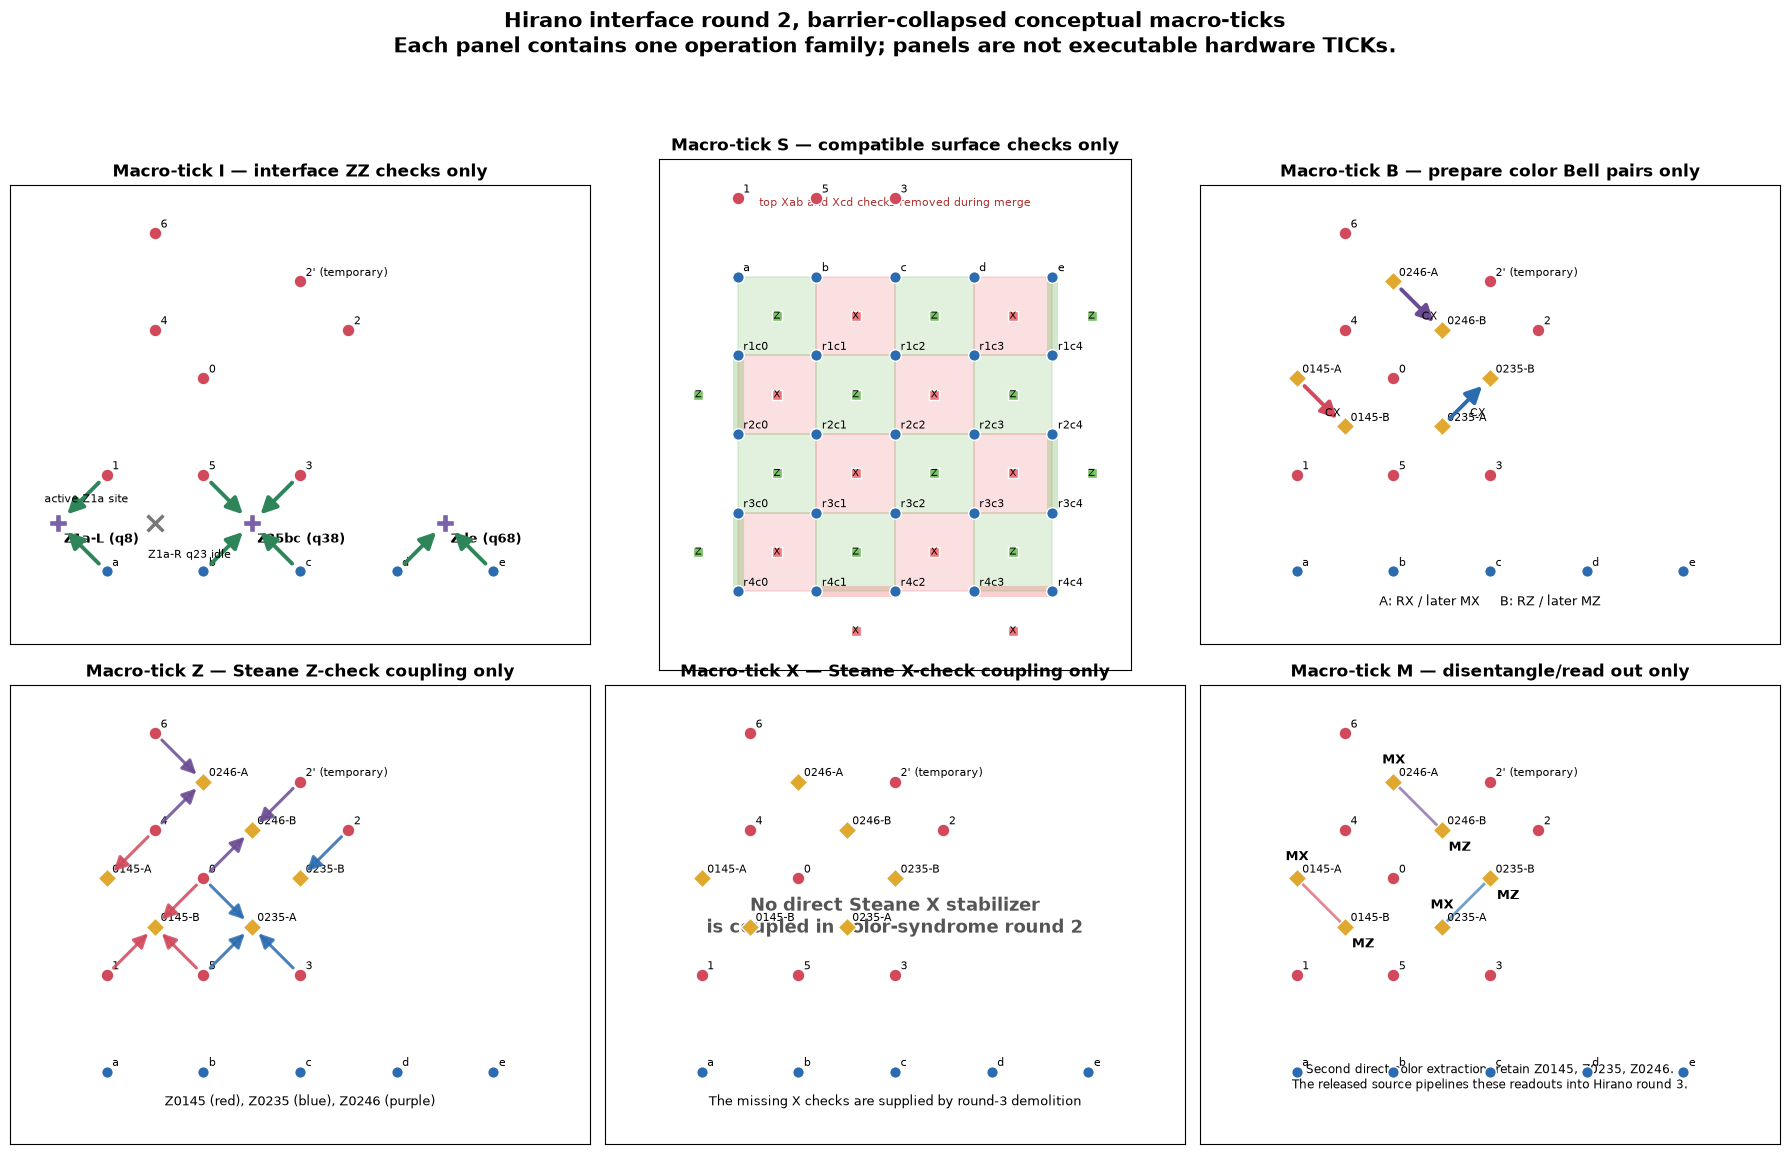

Hirano interface round 3


,Hirano interface round,macro-tick,only operation family shown,checks / actions
0,3,I,interface ZZ checks,"Z1a (right site), Z35bc, Zde"
1,3,S,compatible surface checks,all ordinary surface X/Z checks except top Xab...
2,3,D,Steane demolition,destructively MX-measure Steane data 0–6 (with...
3,3,A,demolition Xab ancilla,"RX q23; CX q23→a,b; MX q23"
4,3,P,derive color-X checks,"X0145ab, X0235, X0246 and logical XL from demo..."
5,3,R,recover top surface-X checks,restart Xab and Xcd in the post-merge surface ...


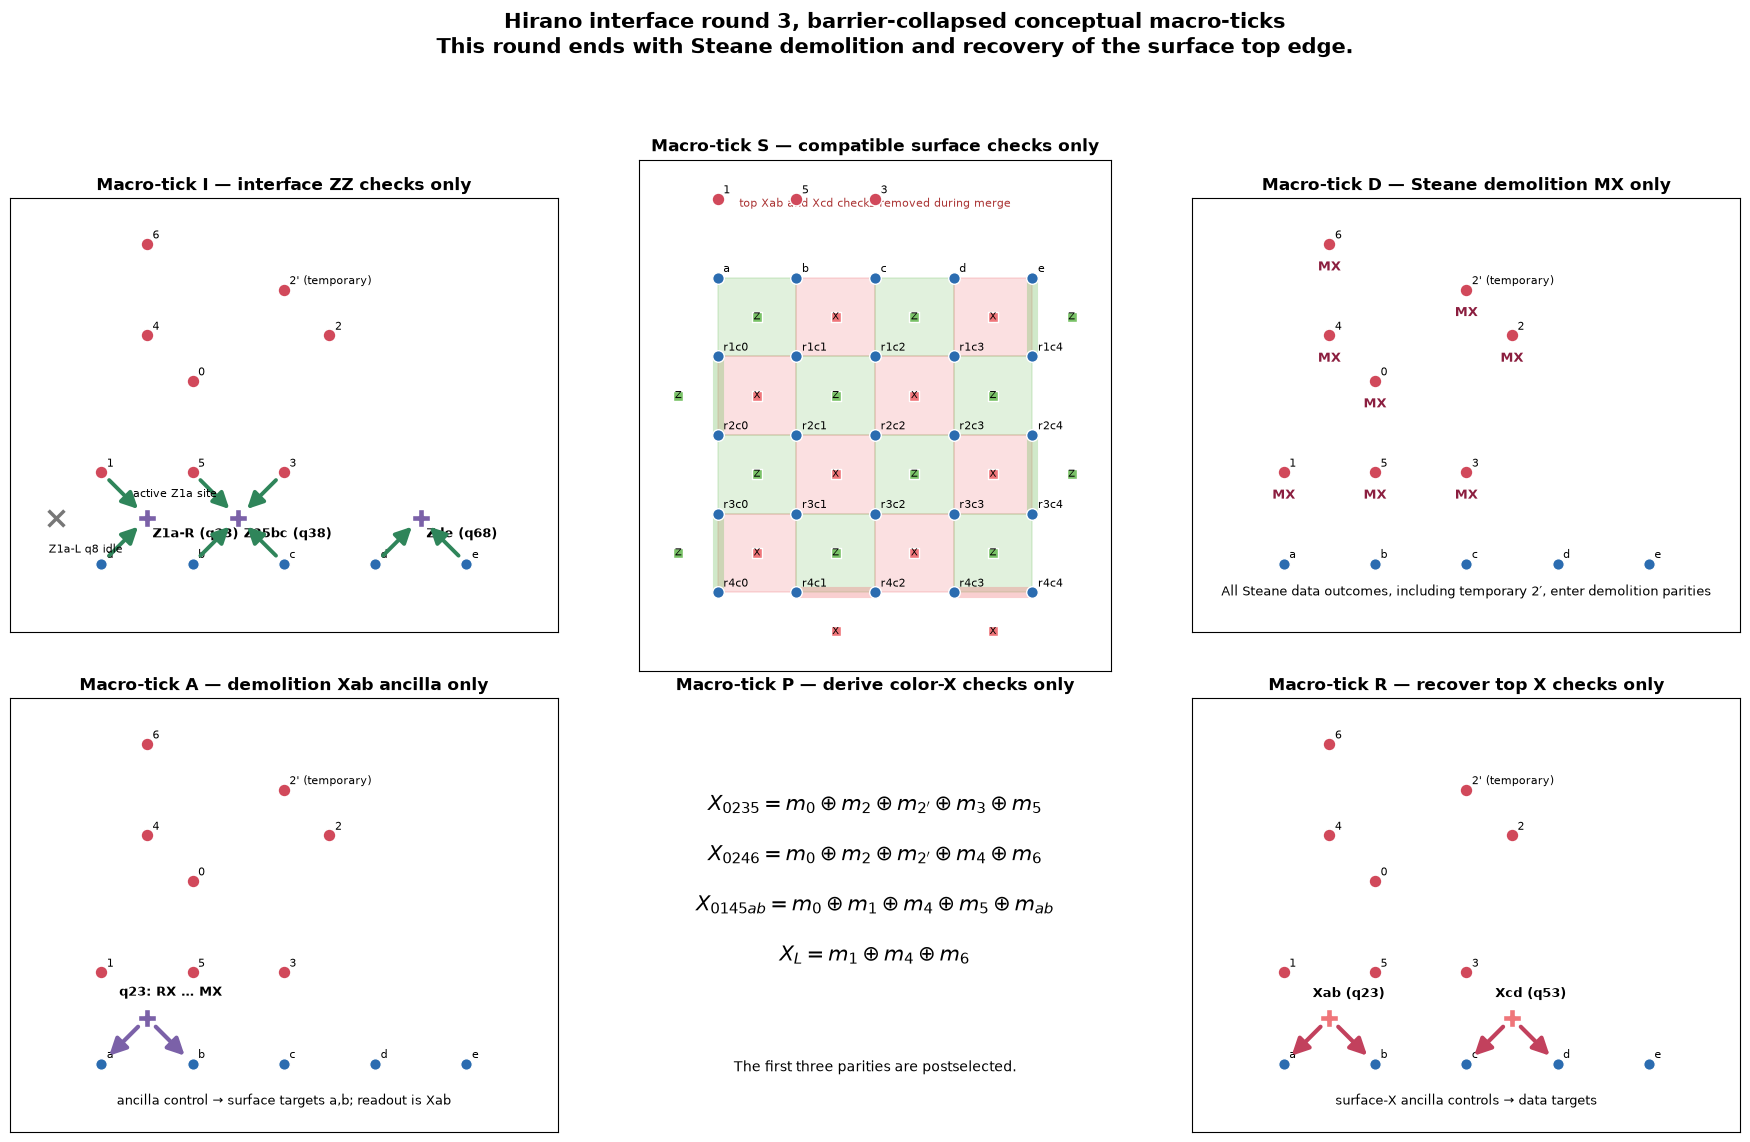

In [7]:
for round_number in (1, 2, 3):
    print(f"Hirano interface round {round_number}")
    display(hirano_interface_round_macro_table(round_number))
    figure = plot_grouped_hirano_interface_round(noiseless, round_number)
    display(figure)
    plt.close(figure)

## 3. What `D16` and `D77` actually mean

`D16` means **detector column 16**, not qubit 16 and not the sixteenth physical
gate. A Stim detector is a parity of earlier measurement-record bits. It does
not make a measurement itself.

For the `0` probe, `D16`, `D46`, and `D77` are three consecutive spacetime
edges of the same surface-Z check. Its ancilla is `q24` at lattice coordinate
$(2,18)$ and its data support is
$\{a,b,(1,19),(3,19)\}$. Explicitly:

$$
D_{16}=m_5\oplus m_{29},\quad
D_{46}=m_{29}\oplus m_{61},\quad
D_{77}=m_{61}\oplus m_{100}.
$$

Thus `D16` is the change between that ancilla's readouts after 5 and 11 TICKs;
`D77` is the change between its readouts after 18 and 25 TICKs. Both are near
the **top-left surface/interface corner**. They are decoded in the `False`
branch and postselected in the `True` branch.

,detector,tag,postselected,declared_tick,measurement_ids,measurement_ticks,measurement_gates,qubits,coordinates,roles
0,D16,SURFACE-Z,False,11,"[5, 29]","[5, 11]","[M, M]","[24, 24]","[(2, 18), (2, 18)]","[Su-Z[a,r1c0,b,r1c1], Su-Z[a,r1c0,b,r1c1]]"
1,D46,SURFACE-Z,False,18,"[29, 61]","[11, 18]","[M, M]","[24, 24]","[(2, 18), (2, 18)]","[Su-Z[a,r1c0,b,r1c1], Su-Z[a,r1c0,b,r1c1]]"
2,D77,SURFACE-Z,False,25,"[61, 100]","[18, 25]","[M, M]","[24, 24]","[(2, 18), (2, 18)]","[Su-Z[a,r1c0,b,r1c1], Su-Z[a,r1c0,b,r1c1]]"


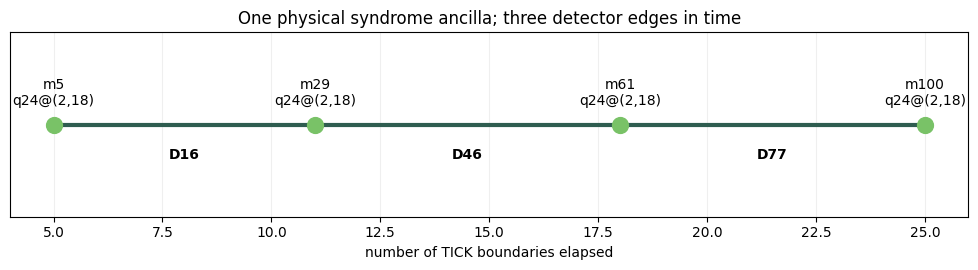

In [7]:
zero_for_detectors = build_protocol("0", error_probability=0.001, full_post_selection=False)
display(detector_registry(zero_for_detectors, [16, 46, 77]))

fig, ax = plt.subplots(figsize=(10, 2.8))
measurement_ticks = [5, 11, 18, 25]
measurement_ids = [5, 29, 61, 100]
ax.scatter(measurement_ticks, [0] * 4, s=130, color="#79c267", zorder=3)
for tick, measurement_id in zip(measurement_ticks, measurement_ids):
    ax.annotate(f"m{measurement_id}\nq24@(2,18)", (tick, 0), xytext=(0, 14),
                textcoords="offset points", ha="center")
for left, right, detector in zip(measurement_ticks, measurement_ticks[1:], ["D16", "D46", "D77"]):
    ax.plot([left, right], [0, 0], color="#2f5d50", linewidth=3)
    ax.annotate(detector, ((left + right) / 2, 0), xytext=(0, -25),
                textcoords="offset points", ha="center", fontweight="bold")
ax.set(xlabel="number of TICK boundaries elapsed", yticks=[], ylim=(-0.35, 0.35),
       title="One physical syndrome ancilla; three detector edges in time")
ax.grid(axis="x", alpha=0.2)
fig.tight_layout();

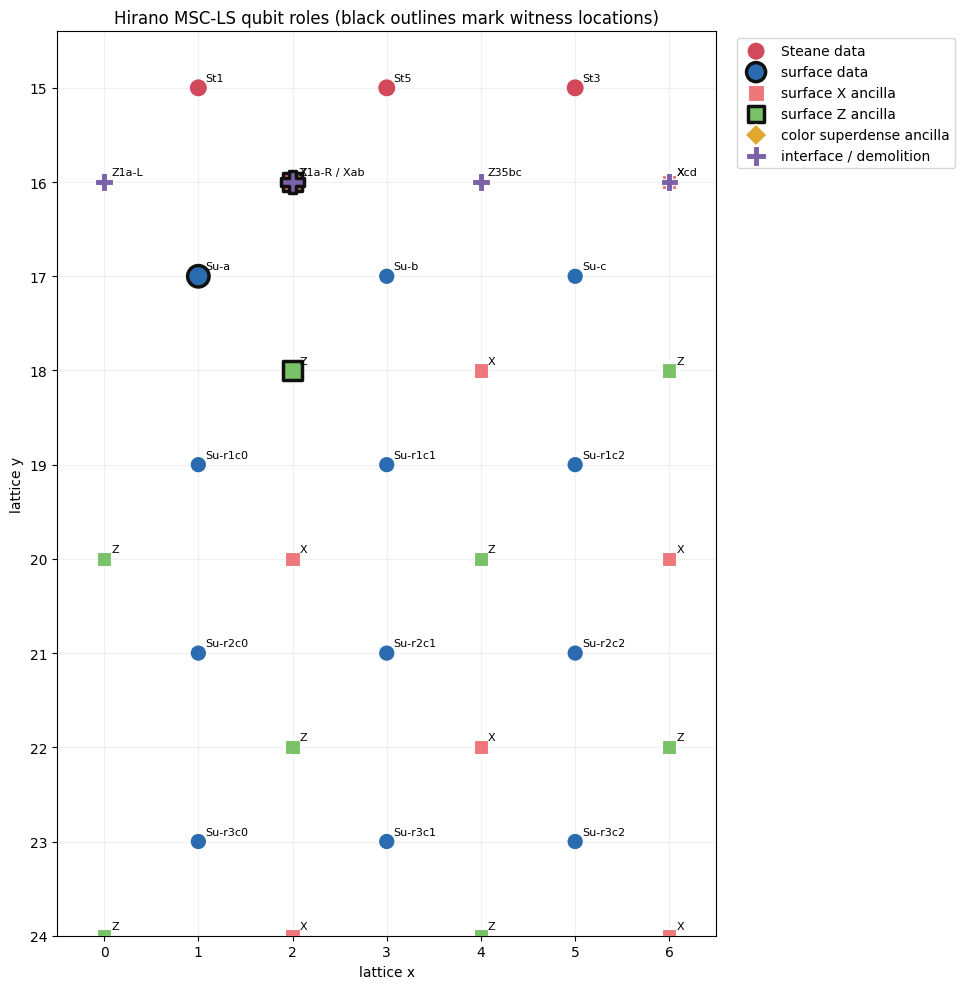

In [8]:
plot_protocol_layout(
    zero_for_detectors,
    highlight={(2, 18), (1, 17), (2, 16)},
    xlim=(-0.5, 6.5),
    ylim=(24, 14.4),
);

## 4. “Two-fault witness” in plain language

For elementary fault $i$, Stim gives a detector-bit pattern $d_i$ and a
logical flip $\ell_i$. Two faults combine by XOR:

$$d_{ij}=d_i\oplus d_j,\qquad \ell_{ij}=\ell_i\oplus\ell_j.$$

A witness consists of two physically possible two-fault histories, A and B,
such that:

1. every postselected detector is zero for both histories;
2. A and B present **exactly the same remaining detector bits** to the decoder;
3. their actual `L0` values are opposite.

No decoder receiving only those detector bits can always be right: it must
return one answer, so at least one of the two histories becomes a logical
failure. Since each history needs two elementary faults, the accepted decoded
logical rate has a nonzero $O(p^2)$ contribution.

`L0` is Stim observable index 0, not inherently logical X or Z. In this
experiment `+` is the logical-Z-error probe and `0` is the logical-X-error
probe.

In [9]:
plus_wrapper, plus_effects, plus_pairs = witness_summary("+")
zero_wrapper, zero_effects, zero_pairs = witness_summary("0")

assert single_fault_decoder_failures(plus_wrapper, plus_effects) == []
assert single_fault_decoder_failures(zero_wrapper, zero_effects) == []

print("+ probe (logical-Z-error diagnostic)")
display(plus_pairs)
print("0 probe (logical-X-error diagnostic)")
display(zero_pairs)
print("No accepted elementary one-fault effect is misdecoded in either probe.")

+ probe (logical-Z-error diagnostic)


,pair,effect_indices,common_accepted_syndrome,actual_L0,PyMatching_prediction,decoder_result
0,A,"(186, 246)","[D16, D22, D25, D56]",0,1,logical failure
1,B,"(206, 341)","[D16, D22, D25, D56]",1,1,correct


0 probe (logical-X-error diagnostic)


,pair,effect_indices,common_accepted_syndrome,actual_L0,PyMatching_prediction,decoder_result
0,A,"(212, 818)","[D16, D77]",0,1,logical failure
1,B,"(185, 1350)","[D16, D77]",1,1,correct


No accepted elementary one-fault effect is misdecoded in either probe.


### Exact physical locations: `+` probe

The failing A history contains two correlated faults immediately after surface
syndrome CNOTs. These are hook-like circuit faults. The competing B history has
the same accepted syndrome but opposite logical class. `D17` cancels within A;
`D21` cancels within B. Both are postselected surface-X detectors, so neither
combined history is rejected.

In [10]:
plus_indices = sorted({i for pair in KNOWN_AMBIGUITIES["+"] for i in pair})
display(fault_table(plus_wrapper, plus_effects, plus_indices))
display(detector_registry(plus_wrapper, [16, 17, 21, 22, 25, 56]))

,effect,detectors,L0,after_TICKs,noise_instruction,representative_Pauli,instruction_offset
0,186,"[D16, D17]",0,8,"DEPOLARIZE2(0.001) 39[coords 4,18] 263[coords ...","YSu-X[b,r1c1,c,r1c2]@(4, 18) * YSu-c@(5, 17)",900
1,206,"[D16, D21]",1,2,"DEPOLARIZE2(0.001) 234[coords 1,19] 24[coords ...","YSu-r1c0@(1, 19)",587
2,246,"[D17, D22, D25, D56]",0,8,"DEPOLARIZE2(0.001) 250[coords 3,21] 40[coords ...","XSu-r2c1@(3, 21) * YSu-Z[r1c1,r2c1,r1c2,r2c2]@...",912
3,341,"[D21, D22, D25, D56]",0,7,"DEPOLARIZE2(0.001) 41[coords 4,22] 250[coords ...","YSu-r2c1@(3, 21)",862


,detector,tag,postselected,declared_tick,measurement_ids,measurement_ticks,measurement_gates,qubits,coordinates,roles
0,D16,SURFACE-Z,False,11,"[5, 29]","[5, 11]","[M, M]","[24, 24]","[(2, 18), (2, 18)]","[Su-Z[a,r1c0,b,r1c1], Su-Z[a,r1c0,b,r1c1]]"
1,D17,SURFACE-X,True,11,"[6, 30]","[5, 11]","[MX, MX]","[39, 39]","[(4, 18), (4, 18)]","[Su-X[b,r1c1,c,r1c2], Su-X[b,r1c1,c,r1c2]]"
2,D21,SURFACE-X,True,11,"[11, 34]","[5, 11]","[MX, MX]","[25, 25]","[(2, 20), (2, 20)]","[Su-X[r1c0,r2c0,r1c1,r2c1], Su-X[r1c0,r2c0,r1c..."
3,D22,SURFACE-Z,False,11,"[12, 35]","[5, 11]","[M, M]","[40, 40]","[(4, 20), (4, 20)]","[Su-Z[r1c1,r2c1,r1c2,r2c2], Su-Z[r1c1,r2c1,r1c..."
4,D25,SURFACE-Z,False,11,"[15, 38]","[5, 11]","[M, M]","[26, 26]","[(2, 22), (2, 22)]","[Su-Z[r2c0,r3c0,r2c1,r3c1], Su-Z[r2c0,r3c0,r2c..."
5,D56,SURFACE-X,False,18,"[39, 71]","[11, 18]","[MX, MX]","[41, 41]","[(4, 22), (4, 22)]","[Su-X[r2c1,r3c1,r2c2,r3c2], Su-X[r2c1,r3c1,r2c..."


In [11]:
plus_failing = deterministic_fault_circuit(
    plus_wrapper.circuit.circuit,
    plus_effects,
    KNOWN_AMBIGUITIES["+"][0],
)
show_timeline(
    plus_failing,
    semantic_labels(plus_wrapper),
    ticks=range(6, 10),
    zoom=1.3,
    annotation_font_size=14,
)

### Exact physical locations: `0` probe

This witness proves hooks are **not** the sole cause. Failing history A is two
`X_ERROR` faults immediately after resets of the same surface-Z ancilla `q24`,
after 6 and 12 TICKs. Their middle endpoint `D46` cancels, leaving only `D16`
and `D77`. Competing history B is the initial reset fault on `q24` plus an X
component of the interface CNOT fault on top-left surface data qubit `a` after
18 TICKs. It has the same two endpoints and the opposite `L0`.

In [12]:
zero_indices = sorted({i for pair in KNOWN_AMBIGUITIES["0"] for i in pair})
display(fault_table(zero_wrapper, zero_effects, zero_indices))
display(detector_registry(zero_wrapper, [16, 46, 77]))

,effect,detectors,L0,after_TICKs,noise_instruction,representative_Pauli,instruction_offset
0,185,[D16],0,0,"X_ERROR(0.001) 24[coords 2,18]","XSu-Z[a,r1c0,b,r1c1]@(2, 18)",501
1,212,"[D16, D46]",0,6,"X_ERROR(0.001) 24[coords 2,18]","XSu-Z[a,r1c0,b,r1c1]@(2, 18)",785
2,818,"[D46, D77]",0,12,"X_ERROR(0.001) 24[coords 2,18]","XSu-Z[a,r1c0,b,r1c1]@(2, 18)",1143
3,1350,[D77],1,18,"DEPOLARIZE2(0.001) 233[coords 1,17] 23[coords ...","XSu-a@(1, 17)",1517


,detector,tag,postselected,declared_tick,measurement_ids,measurement_ticks,measurement_gates,qubits,coordinates,roles
0,D16,SURFACE-Z,False,11,"[5, 29]","[5, 11]","[M, M]","[24, 24]","[(2, 18), (2, 18)]","[Su-Z[a,r1c0,b,r1c1], Su-Z[a,r1c0,b,r1c1]]"
1,D46,SURFACE-Z,False,18,"[29, 61]","[11, 18]","[M, M]","[24, 24]","[(2, 18), (2, 18)]","[Su-Z[a,r1c0,b,r1c1], Su-Z[a,r1c0,b,r1c1]]"
2,D77,SURFACE-Z,False,25,"[61, 100]","[18, 25]","[M, M]","[24, 24]","[(2, 18), (2, 18)]","[Su-Z[a,r1c0,b,r1c1], Su-Z[a,r1c0,b,r1c1]]"


In [13]:
zero_failing = deterministic_fault_circuit(
    zero_wrapper.circuit.circuit,
    zero_effects,
    KNOWN_AMBIGUITIES["0"][0],
)
show_timeline(
    zero_failing,
    semantic_labels(zero_wrapper),
    ticks=range(4, 14),
    zoom=1.2,
    annotation_font_size=14,
)

## 5. Why three-round fault distance becomes a two-fault decoded failure

There are three related but different quantities:

| quantity | exact result here | meaning |
|---|---:|---|
| minimum undetected graphlike logical | 3 faults | Stim's distance sanity check; matches the paper's definition of fault distance |
| accepted one-fault decoder failures | 0 | one elementary fault is handled |
| accepted same-syndrome/opposite-logical histories | 2 faults versus 2 faults | a decoder cannot correct every two-fault history |

This is normal distance-3 decoding logic: a distance-3 spacetime history
corrects one fault, while two faults can make the decoder choose the wrong
logical class. Full postselection asks a different question—how many faults can
produce a logical while **all** detector bits remain zero—and therefore exposes
the three-fault term.

The spatial distance-5 surface patch does not remove the bottleneck because the
merged boundary and color/interface record last only three Hirano rounds. The
additional four surface-only rounds in the decoded branch happen after the
ambiguous transition and cannot reconstruct information that the two histories
made identical.

In [14]:
distance_rows = []
for probe, wrapper, effects in [
    ("+", plus_wrapper, plus_effects),
    ("0", zero_wrapper, zero_effects),
]:
    shortest = wrapper.circuit.circuit.shortest_graphlike_error()
    distance_rows.append(
        {
            "probe": probe,
            "shortest graphlike undetected logical (fault mechanisms)": len(shortest),
            "accepted one-fault decoder failures": len(single_fault_decoder_failures(wrapper, effects)),
            "explicit ambiguous history weight": 2,
        }
    )
display(pd.DataFrame(distance_rows))

,probe,shortest graphlike undetected logical (fault mechanisms),accepted one-fault decoder failures,explicit ambiguous history weight
0,+,3,0,2
1,0,3,0,2


## 6. Why the Monte Carlo fit says “about 2.7”

An exact witness establishes a nonzero quadratic term; it does not say the
quadratic coefficient must dominate at the simulated probabilities. Fit the
saved decoded-branch counts to

$$p_L \approx A p^2+B p^3.$$

The local log-log slope is

$$\alpha_{\rm eff}(p)=\frac{d\log p_L}{d\log p}
=2+\frac{Bp}{A+Bp},$$

which lies between 2 and 3. It tends to 2 as $p\to0$, while appearing around
2.6–2.8 in the Figure-9 window because the cubic mechanisms are still large.

,probe,A (p^2 coefficient),B (p^3 coefficient),A/B crossover p,window power-law slope,local slope at p=0.001
0,+,105.275210,273571.599367,0.000385,2.726869,2.722117
1,0,115.605111,238129.019633,0.000485,2.683213,2.673186


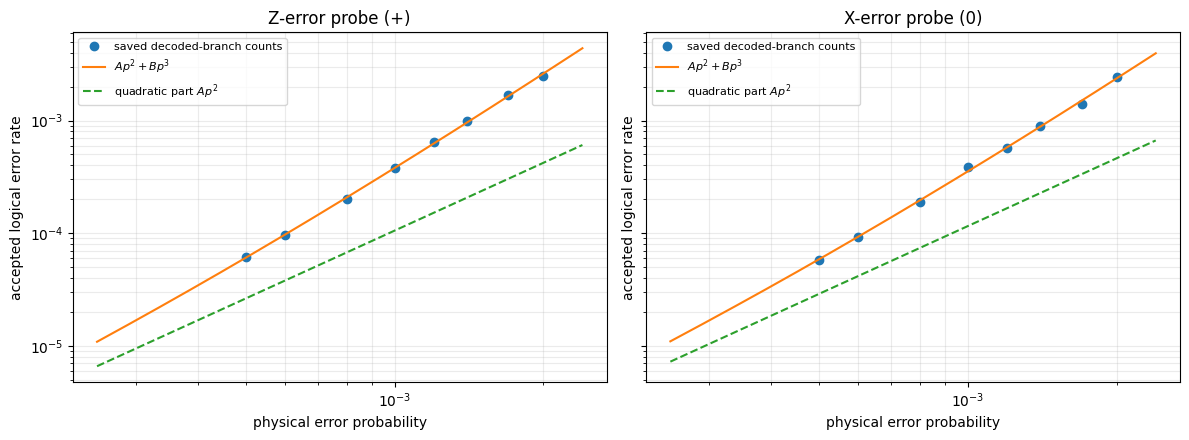

In [15]:
scaling = pd.read_csv(ROOT / "audit" / "false_branch_scaling_results.csv", dtype={"probe": str})
fit_rows = []
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, probe, title in zip(axes, ["+", "0"], ["Z-error probe (+)", "X-error probe (0)"]):
    data = scaling[scaling["probe"] == probe]
    p = data["p"].to_numpy()
    rate = data["logical_error_rate"].to_numpy()
    errors = data["errors"].to_numpy()
    design = np.column_stack([p**2, p**3])
    weights = np.sqrt(errors) / rate
    (A, B), _ = nnls(design * weights[:, None], rate * weights)
    prediction = A * p**2 + B * p**3
    effective_slope = 2 + B * p / (A + B * p)
    power_fit = np.polyfit(np.log(p), np.log(rate), 1, w=np.sqrt(errors))
    fit_rows.append(
        {
            "probe": probe,
            "A (p^2 coefficient)": A,
            "B (p^3 coefficient)": B,
            "A/B crossover p": A / B,
            "window power-law slope": power_fit[0],
            "local slope at p=0.001": 2 + B * 0.001 / (A + B * 0.001),
        }
    )
    dense_p = np.geomspace(p.min() / 2, p.max() * 1.2, 300)
    ax.loglog(p, rate, "o", label="saved decoded-branch counts")
    ax.loglog(dense_p, A * dense_p**2 + B * dense_p**3, label=r"$A p^2+B p^3$")
    ax.loglog(dense_p, A * dense_p**2, "--", label=r"quadratic part $A p^2$")
    ax.set(title=title, xlabel="physical error probability", ylabel="accepted logical error rate")
    ax.grid(which="both", alpha=0.25)
    ax.legend(fontsize=8)
display(pd.DataFrame(fit_rows))
fig.tight_layout();

## 7. What to fix, in the order I would test it

1. **Decide the target behavior.** If “fault distance 3” means the paper's
   minimum-undetected-fault definition, the present circuit already has three;
   postselection or sufficiently strong complementary-gap rejection is what
   converts that into roughly $p^3$ accepted logical scaling. If the goal is
   $p^3$ **while decoding** surface syndromes, the combined transition must
   correct every pair of faults—effectively a distance-5 spacetime target.
2. **Increase the bottleneck depth first.** Parameterize the three
   merged-boundary/interface rounds and try five, while extending the
   compatible surface detector record and the color/demolition schedule. Merely
   appending more surface-only rounds after demolition is not enough.
3. **Repair the temporal corner exposed by `D16–D46–D77`.** Add/reconstruct
   independent information at the initial surface-Z and demolition/interface
   boundaries so that two reset/readout-history faults cannot share endpoints
   with the initial-boundary-plus-interface-data history.
4. **Then optimize the CNOT hooks.** Reorder/orient the surface CNOTs and/or add
   flags so the `+`-probe correlated faults do not align with a short logical
   homology. This can reduce or remove the shown Z-error witness, but the `0`
   witness shows that hook work alone cannot restore cubic decoded scaling.
5. **Do not judge a repair from a slope first.** The regression gate should be
   exact: no accepted one-fault decoder failures and no accepted two-fault
   same-syndrome/opposite-`L0` class. Only then run modest Monte Carlo. The
   tens-of-billions-shot full-postselection sweep is unnecessary for debugging.

An improved decoder alone cannot distinguish the displayed pairs because their
available detector strings are literally equal. A conditional or correlated
decoder may choose the more likely class and reduce the coefficient, but it
cannot make the $p^2$ term vanish unless the circuit supplies additional
information or rejects those syndromes.

In [16]:
assert branch_table.loc[branch_table.full_post_selection == False, "postselected_detectors"].item() == 40
assert branch_table.loc[branch_table.full_post_selection == True, "postselected_detectors"].item() == 135
assert plus_pairs["common_accepted_syndrome"].map(tuple).nunique() == 1
assert zero_pairs["common_accepted_syndrome"].map(tuple).nunique() == 1
assert set(plus_pairs["actual_L0"]) == {0, 1}
assert set(zero_pairs["actual_L0"]) == {0, 1}
print("All notebook audit assertions passed.")

All notebook audit assertions passed.
